# Evaluation Notebook — Adaptive Anti-Doping Defense Engine

Skeleton for dataset validation and detector evaluation.

| Section | Status |
|---|---|
| 1. Setup / imports | Functional (Day 1) |
| 2. Load data | Functional (Day 1) |
| 3. Basic schema / sanity checks | Functional (Day 1) |
| 4. Visual trajectory checks | Functional (Day 2 — v1.1 normal vs transfusion) |
| 5. Anomaly stats | Stub — Day 3+ |
| 6. Precision / recall vs ground truth | Stub — Day 4+ |

## 1. Setup / imports

In [1]:
from __future__ import annotations

import json
import math
from datetime import date
from pathlib import Path

REPO_ROOT = Path("..").resolve()
DATA_DIR = REPO_ROOT / "data"

ATHLETE_FIELDS = ("id", "name", "sport", "age", "baseline_prior_json")
SAMPLE_FIELDS = (
    "id",
    "athlete_id",
    "date",
    "hb",
    "hct",
    "ret_pct",
    "off_score",
    "te_ratio",
    "competition_flag",
    "altitude_flag",
    "injury_flag",
)

HB_MIN, HB_MAX = 12.0, 18.0


def compute_off_score(hb_g_dL: float, ret_pct: float) -> float:
    return (hb_g_dL * 10) - (60 * math.sqrt(ret_pct))


print(f"Repo root: {REPO_ROOT}")
print(f"Data dir:  {DATA_DIR}")

Repo root: C:\Users\srish\OneDrive\Desktop\Projects\Anti-Doping-System
Data dir:  C:\Users\srish\OneDrive\Desktop\Projects\Anti-Doping-System\data


## 2. Load data

In [2]:
athletes_path = DATA_DIR / "athletes.json"
samples_path = DATA_DIR / "samples.json"

with athletes_path.open(encoding="utf-8") as f:
    athletes = json.load(f)
with samples_path.open(encoding="utf-8") as f:
    samples = json.load(f)

athletes_by_id = {a["id"]: a for a in athletes}

samples_by_athlete: dict[int, list[dict]] = {}
for sample in samples:
    samples_by_athlete.setdefault(sample["athlete_id"], []).append(sample)
for rows in samples_by_athlete.values():
    rows.sort(key=lambda s: s["date"])

# Re-derive transfusion-affected athletes from v1.1 spike signature (generator does not
# write ground_truth.json yet). Matches generate_data.py output with seed=42: ids
# [8, 18, 30, 38, 65] — sharp hb/hct step-up + ret_pct drop in a 2-sample window.
GENERATOR_SEED = 42
EXPECTED_ANOMALY_IDS = [8, 18, 30, 38, 65]  # documented from generator stdout


def detect_transfusion_athletes(
    by_athlete: dict[int, list[dict]],
    cumulative_hb_jump: float = 1.1,
    cumulative_ret_drop: float = 0.18,
    window: int = 2,
) -> list[int]:
    """Detect ramped transfusion window (spike may split across 2 consecutive samples)."""
    affected: list[int] = []
    for athlete_id, rows in sorted(by_athlete.items()):
        for i in range(window, len(rows)):
            d_hb = rows[i]["hb"] - rows[i - window]["hb"]
            d_ret = rows[i]["ret_pct"] - rows[i - window]["ret_pct"]
            if d_hb >= cumulative_hb_jump and d_ret <= -cumulative_ret_drop:
                affected.append(athlete_id)
                break
    return affected


anomaly_athlete_ids = detect_transfusion_athletes(samples_by_athlete)
normal_athlete_ids = [a["id"] for a in athletes if a["id"] not in anomaly_athlete_ids]

print(f"Loaded {len(athletes)} athletes from {athletes_path.name} (v1.1 expected: 80)")
print(f"Loaded {len(samples)} samples from {samples_path.name} (v1.1 expected: 400)")
print(f"Transfusion-affected (re-derived): {anomaly_athlete_ids}")
print(f"  expected from generator seed={GENERATOR_SEED}: {EXPECTED_ANOMALY_IDS}")
print(f"  match: {anomaly_athlete_ids == EXPECTED_ANOMALY_IDS}")
print(f"Baseline (unaffected): {len(normal_athlete_ids)} athletes")

Loaded 80 athletes from athletes.json (v1.1 expected: 80)
Loaded 400 samples from samples.json (v1.1 expected: 400)
Transfusion-affected (re-derived): [8, 18, 30, 38, 65]
  expected from generator seed=42: [8, 18, 30, 38, 65]
  match: True
Baseline (unaffected): 75 athletes


## 3. Basic schema / sanity checks

In [3]:
def is_nan(value) -> bool:
    return isinstance(value, float) and math.isnan(value)


def run_sanity_checks(athletes: list[dict], samples: list[dict]) -> tuple[bool, list[str]]:
    errors: list[str] = []

    athlete_ids = set()
    for athlete in athletes:
        for field in ATHLETE_FIELDS:
            if field not in athlete:
                errors.append(f"Athlete missing field '{field}': {athlete}")

        if not isinstance(athlete.get("id"), int):
            errors.append(f"Athlete id must be int, got {type(athlete.get('id'))}")
        if not isinstance(athlete.get("name"), str):
            errors.append(f"Athlete {athlete.get('id')}: name must be str")
        if not isinstance(athlete.get("sport"), str):
            errors.append(f"Athlete {athlete.get('id')}: sport must be str")
        if athlete.get("age") is not None and not isinstance(athlete.get("age"), int):
            errors.append(f"Athlete {athlete.get('id')}: age must be int or null")

        athlete_ids.add(athlete["id"])

    sample_ids = set()
    for sample in samples:
        for field in SAMPLE_FIELDS:
            if field not in sample:
                errors.append(f"Sample {sample.get('id')}: missing field '{field}'")

        sid = sample.get("id")
        if not isinstance(sid, int):
            errors.append(f"Sample id must be int, got {type(sid)}")
        elif sid in sample_ids:
            errors.append(f"Duplicate sample id: {sid}")
        else:
            sample_ids.add(sid)

        if sample.get("athlete_id") not in athlete_ids:
            errors.append(
                f"Sample {sample.get('id')}: invalid athlete_id {sample.get('athlete_id')}"
            )

        try:
            date.fromisoformat(sample["date"])
        except (TypeError, ValueError):
            errors.append(f"Sample {sample.get('id')}: invalid date '{sample.get('date')}'")

        hb = sample.get("hb")
        if hb is None or is_nan(hb):
            errors.append(f"Sample {sample.get('id')}: hb is NaN or missing")
        elif not (HB_MIN <= hb <= HB_MAX):
            errors.append(f"Sample {sample.get('id')}: hb={hb} outside [{HB_MIN}, {HB_MAX}]")

        for field in ("hct", "ret_pct", "off_score", "te_ratio"):
            val = sample.get(field)
            if val is None or is_nan(val):
                errors.append(f"Sample {sample.get('id')}: {field} is NaN or missing")

        for flag in ("competition_flag", "altitude_flag", "injury_flag"):
            if sample.get(flag) not in (True, False):
                errors.append(f"Sample {sample.get('id')}: {flag} must be bool")

        expected_off = round(compute_off_score(sample["hb"], sample["ret_pct"]), 1)
        if sample["off_score"] != expected_off:
            errors.append(
                f"Sample {sample.get('id')}: off_score {sample['off_score']} != expected {expected_off}"
            )

    return len(errors) == 0, errors


passed, sanity_errors = run_sanity_checks(athletes, samples)

print("=" * 60)
print("SANITY CHECK SUMMARY")
print("=" * 60)
print(f"Athletes: {len(athletes)}")
print(f"Samples:  {len(samples)}")
print(f"Hb range: {min(s['hb'] for s in samples):.2f} - {max(s['hb'] for s in samples):.2f} g/dL")
print(f"Result:   {'PASS' if passed else 'FAIL'}")
if sanity_errors:
    print("\nErrors:")
    for err in sanity_errors:
        print(f"  - {err}")

SANITY CHECK SUMMARY
Athletes: 80
Samples:  400
Hb range: 13.61 - 16.72 g/dL
Result:   PASS


## 4. Visual trajectory checks

v1.1 data: 2 unaffected (smooth AR(1) baseline) vs 2 transfusion-affected (sharp hb/hct spike + ret_pct drop).

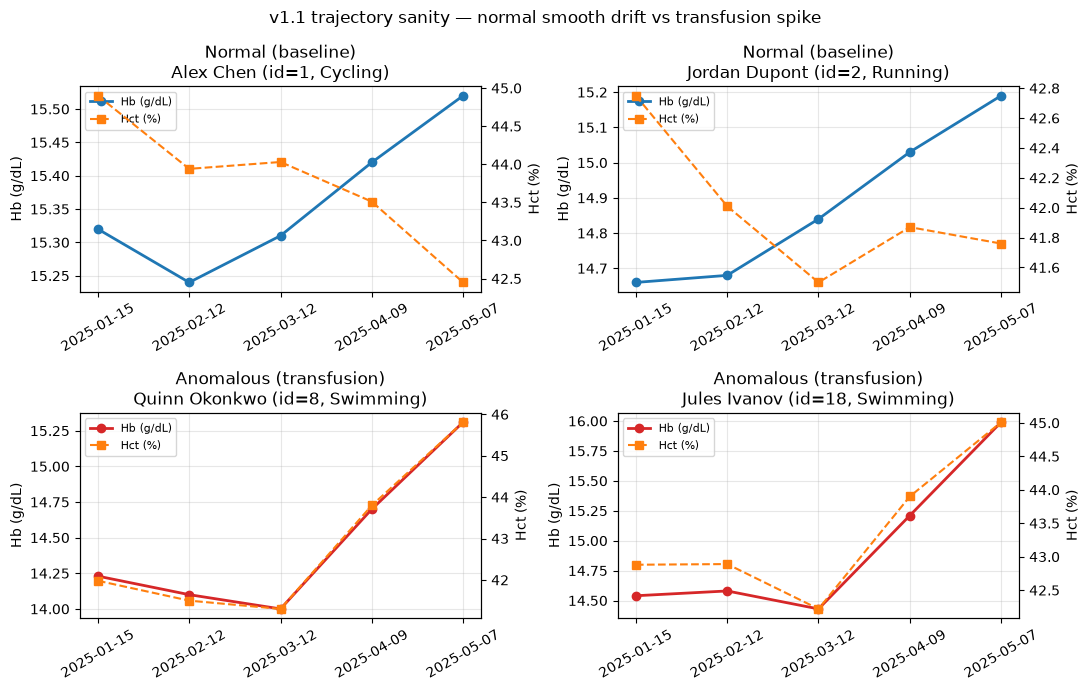

Plotted 4 athletes: normal ids 1, 2 | anomalous ids 8, 18


In [4]:
import matplotlib.pyplot as plt

if len(anomaly_athlete_ids) < 2:
    raise RuntimeError(
        "Expected >=2 transfusion athletes in v1.1 data — re-run ml/generate_data.py, "
        "do not fake plots here."
    )

plot_athletes = [
    (normal_athlete_ids[0], "Normal (baseline)"),
    (normal_athlete_ids[1], "Normal (baseline)"),
    (anomaly_athlete_ids[0], "Anomalous (transfusion)"),
    (anomaly_athlete_ids[1], "Anomalous (transfusion)"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=False)
axes_flat = axes.ravel()

for ax, (athlete_id, group_label) in zip(axes_flat, plot_athletes):
    rows = samples_by_athlete[athlete_id]
    dates = [r["date"] for r in rows]
    hb = [r["hb"] for r in rows]
    hct = [r["hct"] for r in rows]
    athlete = athletes_by_id[athlete_id]
    color = "#d62728" if "Anomalous" in group_label else "#1f77b4"

    ax2 = ax.twinx()
    (hb_line,) = ax.plot(dates, hb, "o-", color=color, linewidth=2, label="Hb (g/dL)")
    (hct_line,) = ax2.plot(dates, hct, "s--", color="#ff7f0e", linewidth=1.5, label="Hct (%)")
    ax.set_title(f"{group_label}\n{athlete['name']} (id={athlete_id}, {athlete['sport']})")
    ax.set_ylabel("Hb (g/dL)")
    ax2.set_ylabel("Hct (%)")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3)
    ax.legend(handles=[hb_line, hct_line], loc="upper left", fontsize=8)

fig.suptitle("v1.1 trajectory sanity — normal smooth drift vs transfusion spike", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Plotted 4 athletes: normal ids {plot_athletes[0][0]}, {plot_athletes[1][0]} | "
      f"anomalous ids {plot_athletes[2][0]}, {plot_athletes[3][0]}")

## 5. Anomaly stats

> Stub — requires anomaly detector + `anomalies` table (Day 3+).

In [5]:
# TODO (Day 3+): compute distribution of anomaly scores, flag rates, etc.
pass

## 6. Precision / recall vs ground truth

> Stub — requires hidden `ground_truth.json` + frozen detector (Day 4+).

In [6]:
# TODO (Day 4+): load ground_truth.json, compute precision/recall at chosen threshold.
pass